<a href="https://colab.research.google.com/github/void-coder-x/DABA_SIG/blob/main/PS3_ATTCK_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PS3 — Connecting Network Anomalies with MITRE ATT&CK Techniques

### SIG-DABA — Security Analytics

**Problem Statement:**
Connect detected network anomalies with relevant MITRE ATT&CK techniques.

### Objective

This notebook maps suspicious network-flow anomalies detected through
unsupervised clustering to candidate MITRE ATT&CK techniques.

### Workflow

Network Anomaly
→ Anomaly Behavior Description
→ Candidate ATT&CK Technique Retrieval
→ Technique Mapping
→ Confidence/Similarity
→ Mapping Results

In [ ]:
## 1. Scope

The objective of this stage is to connect previously detected network
anomalies with relevant MITRE ATT&CK techniques.

The anomaly detection model identifies unusual network behavior, but an
anomaly score alone does not determine the exact attack technique.

Therefore, this stage produces **candidate MITRE ATT&CK mappings** that
can be further validated in later stages.

### PS3 focuses on

- Loading suspicious network flows
- Describing anomalous behavior
- Loading MITRE ATT&CK techniques
- Comparing anomaly behavior with technique descriptions
- Producing candidate technique mappings
- Summarizing technique associations

### PS3 does not implement

- A complete security RAG assistant
- LLM fine-tuning
- A production security interface
- Final attack confirmation

In [6]:
import pandas as pd
import numpy as np
import requests
import json
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
results = pd.read_csv("/content/top_anomalies.csv")

print("Shape:", results.shape)
display(results.head())

Shape: (20, 65)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Cluster,Anomaly_Score,Predicted_Anomaly
0,80,110291452,77620,104354,459634,227000000,1460,0,5.921592,10.144797,...,45000000,45000000,65200000.0,0.0,65200000,65200000,BENIGN,0,212.200790,1
1,80,116552065,131,168,85540,147271,1333,0,652.977099,664.692797,...,106000000,106000000,10000000.0,0.0,10000000,10000000,BENIGN,0,200.996838,1
2,8053,115509371,74,72,6422,1053,312,6,86.783784,70.536743,...,105000000,105000000,5020472.0,0.0,5020472,5020472,BENIGN,0,198.767145,1
3,443,98644475,172,166,156402,126938,1704,6,909.313954,729.934136,...,85900000,85900000,9801501.0,0.0,9801501,9801501,BENIGN,0,163.803763,1
4,443,97397596,67,55,50295,40573,1685,6,750.671642,751.639146,...,83500000,83500000,9796547.0,0.0,9796547,9796547,BENIGN,0,158.146933,1


In [8]:
required_columns = [
    "Cluster",
    "Anomaly_Score",
    "Predicted_Anomaly"
]

missing_columns = [
    col for col in required_columns
    if col not in results.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required PS2 columns are available.")

All required PS2 columns are available.


In [9]:
anomalies = results[
    results["Predicted_Anomaly"] == 1
].copy()

print("Number of detected anomalies:", len(anomalies))

display(
    anomalies[
        ["Cluster", "Anomaly_Score", "Predicted_Anomaly"]
    ].head(10)
)

Number of detected anomalies: 20


,Cluster,Anomaly_Score,Predicted_Anomaly
0,0,212.200790,1
1,0,200.996838,1
2,0,198.767145,1
3,0,163.803763,1
4,0,158.146933,1
5,0,152.579626,1
6,0,138.276144,1
7,0,137.887427,1
8,0,125.936221,1
9,0,125.077515,1


In [10]:
def describe_anomaly(row):
    description = []

    if "Flow Duration" in row.index:
        description.append(
            f"flow duration {row['Flow Duration']:.2f}"
        )

    if "Total Fwd Packets" in row.index:
        description.append(
            f"forward packets {row['Total Fwd Packets']:.0f}"
        )

    if "Total Backward Packets" in row.index:
        description.append(
            f"backward packets {row['Total Backward Packets']:.0f}"
        )

    if "Flow Bytes/s" in row.index:
        description.append(
            f"flow byte rate {row['Flow Bytes/s']:.2f}"
        )

    if "Flow Packets/s" in row.index:
        description.append(
            f"flow packet rate {row['Flow Packets/s']:.2f}"
        )

    return ", ".join(description)


anomalies["Behavior_Description"] = anomalies.apply(
    describe_anomaly,
    axis=1
)

display(
    anomalies[
        ["Cluster", "Anomaly_Score", "Behavior_Description"]
    ].head(10)
)

,Cluster,Anomaly_Score,Behavior_Description
0,0,212.200790,"flow duration 110291452.00, forward packets 77..."
1,0,200.996838,"flow duration 116552065.00, forward packets 13..."
2,0,198.767145,"flow duration 115509371.00, forward packets 74..."
3,0,163.803763,"flow duration 98644475.00, forward packets 172..."
4,0,158.146933,"flow duration 97397596.00, forward packets 67,..."
5,0,152.579626,"flow duration 113960538.00, forward packets 40..."
6,0,138.276144,"flow duration 119399324.00, forward packets 29..."
7,0,137.887427,"flow duration 119889314.00, forward packets 41..."
8,0,125.936221,"flow duration 119870695.00, forward packets 74..."
9,0,125.077515,"flow duration 117333726.00, forward packets 49..."


In [11]:
MITRE_URL = (
    "https://raw.githubusercontent.com/mitre-attack/"
    "attack-stix-data/master/enterprise-attack/"
    "enterprise-attack.json"
)

response = requests.get(MITRE_URL)

if response.status_code == 200:
    mitre_data = response.json()
    print("MITRE ATT&CK data loaded successfully.")
else:
    raise Exception(
        f"Failed to download MITRE ATT&CK data. "
        f"Status code: {response.status_code}"
    )

MITRE ATT&CK data loaded successfully.


In [12]:
techniques = []

for obj in mitre_data["objects"]:

    if obj.get("type") != "attack-pattern":
        continue

    if obj.get("revoked", False):
        continue

    if obj.get("x_mitre_deprecated", False):
        continue

    technique_id = None

    for ref in obj.get("external_references", []):
        if ref.get("source_name") == "mitre-attack":
            external_id = ref.get("external_id", "")

            if external_id.startswith("T"):
                technique_id = external_id
                break

    if technique_id:

        techniques.append({
            "Technique_ID": technique_id,
            "Technique_Name": obj.get("name", ""),
            "Description": obj.get("description", "")
        })

techniques_df = pd.DataFrame(techniques)

print("Number of ATT&CK techniques:", len(techniques_df))

display(techniques_df.head())

Number of ATT&CK techniques: 697


,Technique_ID,Technique_Name,Description
0,T1055.011,Extra Window Memory Injection,Adversaries may inject malicious code into pro...
1,T1053.005,Scheduled Task,Adversaries may abuse the Windows Task Schedul...
2,T1205.002,Socket Filters,Adversaries may attach filters to a network so...
3,T1560.001,Archive via Utility,Adversaries may use utilities to compress and/...
4,T1021.005,VNC,Adversaries may use [Valid Accounts](https://a...


In [13]:
techniques_df["Technique_Text"] = (
    techniques_df["Technique_Name"].fillna("") +
    " " +
    techniques_df["Description"].fillna("")
)

techniques_df[
    ["Technique_ID", "Technique_Name"]
].head(10)

,Technique_ID,Technique_Name
0,T1055.011,Extra Window Memory Injection
1,T1053.005,Scheduled Task
2,T1205.002,Socket Filters
3,T1560.001,Archive via Utility
4,T1021.005,VNC
5,T1047,Windows Management Instrumentation
6,T1687,Exploitation for Defense Impairment
7,T1113,Screen Capture
8,T1027.011,Fileless Storage
9,T1037,Boot or Logon Initialization Scripts


In [14]:
anomaly_text = (
    anomalies["Behavior_Description"]
    .fillna("")
    .astype(str)
)

technique_text = (
    techniques_df["Technique_Text"]
    .fillna("")
    .astype(str)
)

print("Anomaly descriptions:", len(anomaly_text))
print("Technique descriptions:", len(technique_text))

Anomaly descriptions: 20
Technique descriptions: 697


In [15]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

combined_text = pd.concat(
    [anomaly_text, technique_text],
    ignore_index=True
)

tfidf_matrix = vectorizer.fit_transform(combined_text)

anomaly_vectors = tfidf_matrix[:len(anomaly_text)]
technique_vectors = tfidf_matrix[len(anomaly_text):]

print("Vectorization completed.")

Vectorization completed.


In [16]:
similarity_matrix = cosine_similarity(
    anomaly_vectors,
    technique_vectors
)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (20, 697)


In [17]:
TOP_K = 3

mapping_results = []

for i, (_, anomaly) in enumerate(anomalies.iterrows()):

    similarities = similarity_matrix[i]

    top_indices = np.argsort(
        similarities
    )[::-1][:TOP_K]

    for idx in top_indices:

        mapping_results.append({
            "Cluster": anomaly["Cluster"],
            "Anomaly_Score": anomaly["Anomaly_Score"],
            "Behavior_Description":
                anomaly["Behavior_Description"],
            "Technique_ID":
                techniques_df.iloc[idx]["Technique_ID"],
            "Technique_Name":
                techniques_df.iloc[idx]["Technique_Name"],
            "Similarity_Score":
                similarities[idx]
        })

mapping_df = pd.DataFrame(mapping_results)

display(mapping_df.head(15))

,Cluster,Anomaly_Score,Behavior_Description,Technique_ID,Technique_Name,Similarity_Score
0,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1574,Hijack Execution Flow,0.137290
1,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1205,Traffic Signaling,0.080391
2,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1499.001,OS Exhaustion Flood,0.064841
3,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1574,Hijack Execution Flow,0.140141
4,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1205,Traffic Signaling,0.082060
5,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1499.001,OS Exhaustion Flood,0.066188
6,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1574,Hijack Execution Flow,0.144069
7,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1205,Traffic Signaling,0.084360
8,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1499.001,OS Exhaustion Flood,0.068043
9,0,163.803763,"flow duration 98644475.00, forward packets 172...",T1574,Hijack Execution Flow,0.140694


In [18]:
def similarity_category(score):

    if score >= 0.30:
        return "High"

    elif score >= 0.15:
        return "Moderate"

    else:
        return "Low"


mapping_df["Similarity_Category"] = (
    mapping_df["Similarity_Score"]
    .apply(similarity_category)
)

display(mapping_df.head(15))

,Cluster,Anomaly_Score,Behavior_Description,Technique_ID,Technique_Name,Similarity_Score,Similarity_Category
0,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1574,Hijack Execution Flow,0.137290,Low
1,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1205,Traffic Signaling,0.080391,Low
2,0,212.200790,"flow duration 110291452.00, forward packets 77...",T1499.001,OS Exhaustion Flood,0.064841,Low
3,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1574,Hijack Execution Flow,0.140141,Low
4,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1205,Traffic Signaling,0.082060,Low
5,0,200.996838,"flow duration 116552065.00, forward packets 13...",T1499.001,OS Exhaustion Flood,0.066188,Low
6,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1574,Hijack Execution Flow,0.144069,Low
7,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1205,Traffic Signaling,0.084360,Low
8,0,198.767145,"flow duration 115509371.00, forward packets 74...",T1499.001,OS Exhaustion Flood,0.068043,Low
9,0,163.803763,"flow duration 98644475.00, forward packets 172...",T1574,Hijack Execution Flow,0.140694,Low


In [19]:
candidate_mappings = mapping_df[
    mapping_df["Similarity_Score"] >= 0.15
].copy()

print(
    "Candidate mappings:",
    len(candidate_mappings)
)

display(candidate_mappings.head(20))

Candidate mappings: 0


,Cluster,Anomaly_Score,Behavior_Description,Technique_ID,Technique_Name,Similarity_Score,Similarity_Category


In [20]:
technique_summary = (
    candidate_mappings
    .groupby(
        ["Technique_ID", "Technique_Name"]
    )
    .agg(
        Anomaly_Count=("Cluster", "count"),
        Average_Similarity=("Similarity_Score", "mean"),
        Maximum_Similarity=("Similarity_Score", "max")
    )
    .reset_index()
    .sort_values(
        "Average_Similarity",
        ascending=False
    )
)

display(technique_summary.head(20))

,Technique_ID,Technique_Name,Anomaly_Count,Average_Similarity,Maximum_Similarity


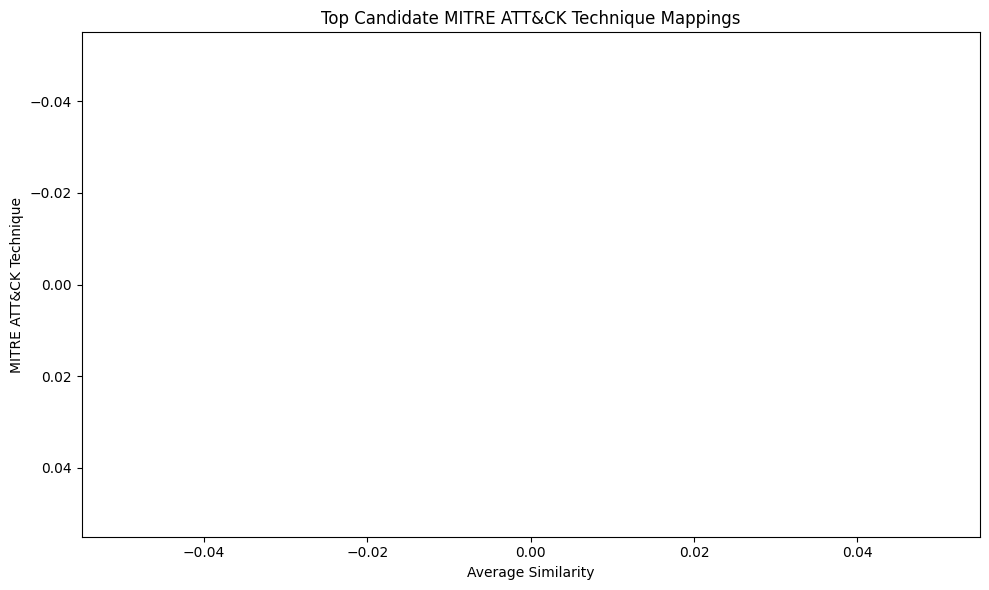

In [21]:
import matplotlib.pyplot as plt

top_techniques = technique_summary.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_techniques["Technique_Name"],
    top_techniques["Average_Similarity"]
)

plt.xlabel("Average Similarity")
plt.ylabel("MITRE ATT&CK Technique")
plt.title("Top Candidate MITRE ATT&CK Technique Mappings")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [22]:
if len(candidate_mappings) > 0:

    example = candidate_mappings.iloc[0]

    print("Example Anomaly-to-ATT&CK Mapping")
    print("=" * 50)

    print(
        "Cluster:",
        example["Cluster"]
    )

    print(
        "Anomaly Score:",
        round(example["Anomaly_Score"], 4)
    )

    print(
        "Behavior:",
        example["Behavior_Description"]
    )

    print(
        "Candidate Technique:",
        example["Technique_ID"],
        "-",
        example["Technique_Name"]
    )

    print(
        "Similarity:",
        round(example["Similarity_Score"], 4)
    )

    print(
        "Category:",
        example["Similarity_Category"]
    )

In [23]:
import os

os.makedirs(
    "/content/PS3_results",
    exist_ok=True
)

mapping_df.to_csv(
    "/content/PS3_results/anomaly_technique_mapping.csv",
    index=False
)

technique_summary.to_csv(
    "/content/PS3_results/technique_summary.csv",
    index=False
)

print("PS3 results saved successfully.")

PS3 results saved successfully.


In [ ]:
## Limitations

1. The anomaly detector is unsupervised and identifies unusual network
   behavior rather than confirmed attacks.

2. The generated ATT&CK mappings are candidate mappings and should not
   be interpreted as confirmed attack classifications.

3. TF-IDF and cosine similarity provide a lightweight semantic matching
   approach but may not capture deeper cybersecurity semantics.

4. Network-flow features alone may not provide enough context to identify
   a specific ATT&CK technique.

5. The similarity thresholds used in this prototype are experimental and
   require validation using labeled scenarios.

6. Further improvement can use richer behavior descriptions, explicit
   ATT&CK relationships, embeddings, and an LLM-based RAG workflow.

In [ ]:
## Conclusion

This stage connects detected network anomalies with candidate MITRE
ATT&CK techniques.

The workflow converts anomalous network-flow characteristics into
behavior descriptions and compares them with MITRE ATT&CK technique
descriptions.

The resulting mappings provide a foundation for subsequent stages,
including MITRE knowledge-base indexing, prompt design, RAG-based
analysis, and validation.